# CIFAR-10 Model Serving Test

이 노트북은 TensorFlow Serving으로 배포된 CIFAR-10 모델을 테스트합니다.
This notebook tests the CIFAR-10 model deployed with TensorFlow Serving.

## 1. 라이브러리 임포트

In [1]:
import json
import requests
import numpy as np
import matplotlib.pyplot as plt

## 2. 테스트 이미지 생성 및 시각화

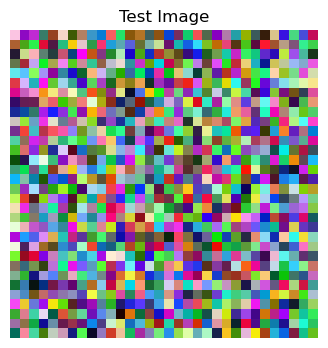

In [2]:
# 랜덤 테스트 이미지 생성 (Create random test image)
test_image = np.random.rand(32, 32, 3).astype('float32')

# 이미지 시각화 (Visualize image)
plt.figure(figsize=(4, 4))
plt.imshow(test_image)
plt.axis('off')
plt.title('Test Image')
plt.show()

# 모델 입력을 위한 데이터 준비 (Prepare data for model input)
test_data = [test_image.tolist()]

## 3. 모델 예측 수행

In [3]:
# TensorFlow Serving에 요청 보내기 (Send request to TensorFlow Serving)
headers = {"content-type": "application/json"}
data = json.dumps({
    "signature_name": "serving_default",
    "instances": test_data
})
url = "http://localhost:8501/v1/models/cifar10_model:predict"

# 예측 결과 받기 (Get prediction results)
response = requests.post(url, data=data, headers=headers)

if response.status_code == 200:
    predictions = response.json()['predictions']
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    
    # 가장 높은 확률의 클래스 찾기 (Find class with highest probability)
    probs = predictions[0]
    max_prob_index = np.argmax(probs)
    
    print(f"예측된 클래스 (Predicted class): {class_names[max_prob_index]} (클래스 {max_prob_index})")
    print(f"\n각 클래스별 예측 확률 (Prediction probabilities for each class):")
    for i, (name, prob) in enumerate(zip(class_names, probs)):
        print(f"{name}: {prob:.4f}")
else:
    print("에러 (Error):", response.text)

예측된 클래스 (Predicted class): automobile (클래스 1)

각 클래스별 예측 확률 (Prediction probabilities for each class):
airplane: 0.0000
automobile: 0.9993
bird: 0.0000
cat: 0.0000
deer: 0.0000
dog: 0.0000
frog: 0.0003
horse: 0.0000
ship: 0.0000
truck: 0.0003


## 4. 예측 결과 시각화

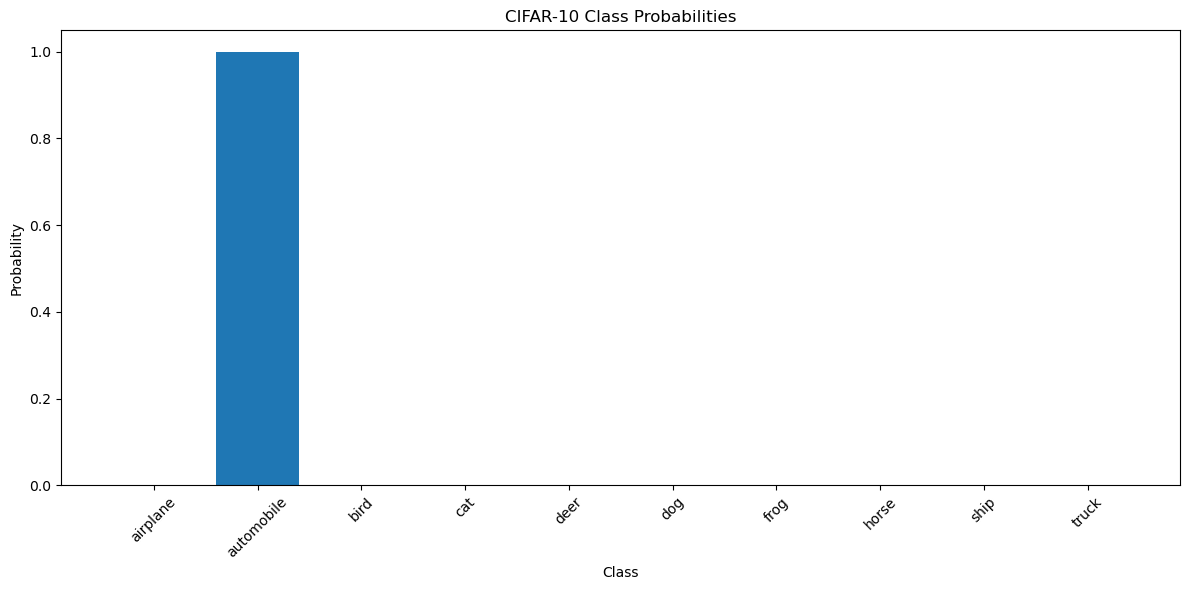

In [4]:
# 예측 결과 시각화 (Visualize prediction results)
plt.figure(figsize=(12, 6))
plt.bar(class_names, predictions[0])
plt.xticks(rotation=45)
plt.title('CIFAR-10 Class Probabilities')
plt.xlabel('Class')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

## 5. 실제 CIFAR-10 이미지로 테스트 

170500096/170498071 [==============================] - 62s 0us/step


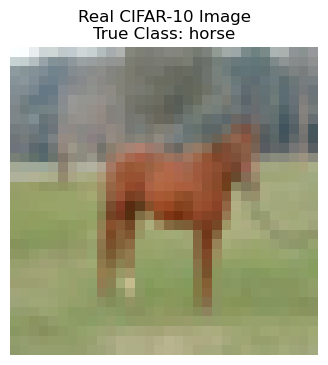

실제 클래스 (True class): horse
예측된 클래스 (Predicted class): horse


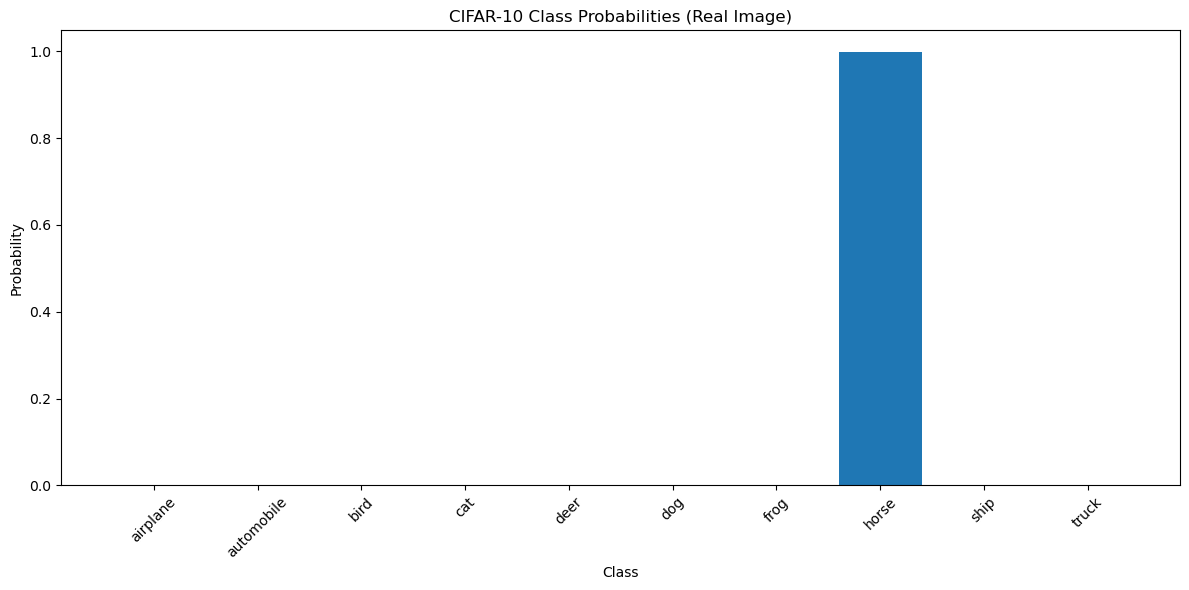

In [5]:
# CIFAR-10 데이터셋 로드 (Load CIFAR-10 dataset)
from tensorflow.keras.datasets import cifar10

(_, _), (x_test, y_test) = cifar10.load_data()
x_test = x_test.astype('float32') / 255.0

# 테스트할 이미지 선택 (Select an image to test)
test_idx = np.random.randint(0, len(x_test))
real_test_image = x_test[test_idx]
real_label = y_test[test_idx][0]

# 이미지 시각화 (Visualize image)
plt.figure(figsize=(4, 4))
plt.imshow(real_test_image)
plt.axis('off')
plt.title(f'Real CIFAR-10 Image\nTrue Class: {class_names[real_label]}')
plt.show()

# 예측 수행 (Make prediction)
test_data = [real_test_image.tolist()]
data = json.dumps({
    "signature_name": "serving_default",
    "instances": test_data
})

response = requests.post(url, data=data, headers=headers)

if response.status_code == 200:
    predictions = response.json()['predictions']
    max_prob_index = np.argmax(predictions[0])
    
    print(f"실제 클래스 (True class): {class_names[real_label]}")
    print(f"예측된 클래스 (Predicted class): {class_names[max_prob_index]}")
    
    # 예측 확률 시각화 (Visualize prediction probabilities)
    plt.figure(figsize=(12, 6))
    plt.bar(class_names, predictions[0])
    plt.xticks(rotation=45)
    plt.title('CIFAR-10 Class Probabilities (Real Image)')
    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.tight_layout()
    plt.show()
else:
    print("에러 (Error):", response.text)